In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

df = pd.read_csv('/kaggle/input/travel-dataset/Travel.csv')
df.head()

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


# Eploratory Data analysis for the travel Dataset.
- Imputing the missing values
- Data cleaning
- Data Visualisation

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [3]:
df.describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4662.000000,4888.000000,4637.000000,4888.000000,4843.000000,4862.000000,4748.000000,4888.000000,4888.000000,4888.000000,4822.000000,4655.000000
mean,202443.500000,0.188216,37.622265,1.654255,15.490835,2.905074,3.708445,3.581037,3.236521,0.290917,3.078151,0.620295,1.187267,23619.853491
std,1411.188388,0.390925,9.316387,0.916583,8.519643,0.724891,1.002509,0.798009,1.849019,0.454232,1.365792,0.485363,0.857861,5380.698361
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,201221.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,20346.000000
50%,202443.500000,0.000000,36.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,3.000000,1.000000,1.000000,22347.000000
75%,203665.250000,0.000000,44.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.000000,1.000000,4.000000,1.000000,2.000000,25571.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,5.000000,1.000000,3.000000,98678.000000


In [4]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [5]:
# Converting the column names to lowercase.
df.columns = [col.replace(" ", "_") for col in df.columns]

# Alternatively, you could use .str.replace for more complex patterns
df.columns = df.columns.str.replace(r"([a-z])([A-Z])", r"\1_\2", regex=True).str.lower()

In [6]:
df.columns

Index(['customer_id', 'prod_taken', 'age', 'typeof_contact', 'city_tier',
       'duration_of_pitch', 'occupation', 'gender',
       'number_of_person_visiting', 'number_of_followups', 'product_pitched',
       'preferred_property_star', 'marital_status', 'number_of_trips',
       'passport', 'pitch_satisfaction_score', 'own_car',
       'number_of_children_visiting', 'designation', 'monthly_income'],
      dtype='object')

# Checking for the Missing Values.
- imputing the missing values with mean, median and mode.

In [7]:
df.isnull().sum()

customer_id                      0
prod_taken                       0
age                            226
typeof_contact                  25
city_tier                        0
duration_of_pitch              251
occupation                       0
gender                           0
number_of_person_visiting        0
number_of_followups             45
product_pitched                  0
preferred_property_star         26
marital_status                   0
number_of_trips                140
passport                         0
pitch_satisfaction_score         0
own_car                          0
number_of_children_visiting     66
designation                      0
monthly_income                 233
dtype: int64

In [8]:
df.columns[df.isnull().any()]

Index(['age', 'typeof_contact', 'duration_of_pitch', 'number_of_followups',
       'preferred_property_star', 'number_of_trips',
       'number_of_children_visiting', 'monthly_income'],
      dtype='object')

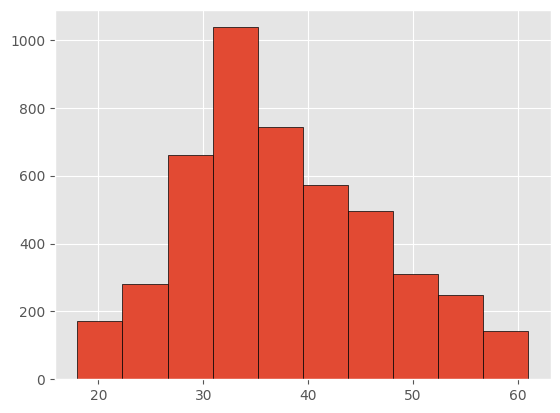

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
plt.hist(df['age'], edgecolor='black')
plt.show()

In [10]:
df['age'] = df['age'].fillna(df['age'].mean())

In [11]:
df[['typeof_contact', 'duration_of_pitch', 'number_of_followups',
       'preferred_property_star', 'number_of_trips',
       'number_of_children_visiting', 'monthly_income']]

,typeof_contact,duration_of_pitch,number_of_followups,preferred_property_star,number_of_trips,number_of_children_visiting,monthly_income
0,Self Enquiry,6.0,3.0,3.0,1.0,0.0,20993.0
1,Company Invited,14.0,4.0,4.0,2.0,2.0,20130.0
2,Self Enquiry,8.0,4.0,3.0,7.0,0.0,17090.0
3,Company Invited,9.0,3.0,3.0,2.0,1.0,17909.0
4,Self Enquiry,8.0,3.0,4.0,1.0,0.0,18468.0
...,...,...,...,...,...,...,...
4883,Self Enquiry,9.0,5.0,4.0,2.0,1.0,26576.0
4884,Company Invited,31.0,5.0,3.0,3.0,2.0,21212.0
4885,Self Enquiry,17.0,4.0,4.0,7.0,3.0,31820.0
4886,Self Enquiry,16.0,4.0,3.0,3.0,2.0,20289.0


In [12]:
mode_value = df['typeof_contact'].mode()[0]
df['typeof_contact'] = df['typeof_contact'].fillna(mode_value)

In [13]:
print(df['number_of_followups'].value_counts())
print(df['preferred_property_star'].value_counts())
print(df['number_of_trips'].value_counts())
print(df['number_of_children_visiting'].value_counts())
print(df['monthly_income'].value_counts())

number_of_followups
4.0    2068
3.0    1466
5.0     768
2.0     229
1.0     176
6.0     136
Name: count, dtype: int64
preferred_property_star
3.0    2993
5.0     956
4.0     913
Name: count, dtype: int64
number_of_trips
2.0     1464
3.0     1079
1.0      620
4.0      478
5.0      458
6.0      322
7.0      218
8.0      105
19.0       1
21.0       1
20.0       1
22.0       1
Name: count, dtype: int64
number_of_children_visiting
1.0    2080
2.0    1335
0.0    1082
3.0     325
Name: count, dtype: int64
monthly_income
20855.0    7
21288.0    7
17342.0    7
21020.0    7
24950.0    6
          ..
17074.0    1
24250.0    1
21077.0    1
24714.0    1
21471.0    1
Name: count, Length: 2475, dtype: int64


In [14]:
df['monthly_income'] = df['monthly_income'].fillna(df['monthly_income'].median())
df['number_of_children_visiting'] = df['number_of_children_visiting'].fillna(df['number_of_children_visiting'].mode()[0])

In [15]:
df['number_of_trips'] = df['number_of_trips'].fillna(df['number_of_trips'].median())
df['preferred_property_star'] = df['preferred_property_star'].fillna(df['preferred_property_star'].mode()[0])
df['number_of_followups'] = df['number_of_followups'].fillna(df['number_of_followups'].median())

In [16]:
df['duration_of_pitch'] = df['duration_of_pitch'].fillna(df['duration_of_pitch'].median())

In [17]:
df.isnull().sum()

customer_id                    0
prod_taken                     0
age                            0
typeof_contact                 0
city_tier                      0
duration_of_pitch              0
occupation                     0
gender                         0
number_of_person_visiting      0
number_of_followups            0
product_pitched                0
preferred_property_star        0
marital_status                 0
number_of_trips                0
passport                       0
pitch_satisfaction_score       0
own_car                        0
number_of_children_visiting    0
designation                    0
monthly_income                 0
dtype: int64

In [18]:
# dropping the customer id column
df.drop('customer_id', axis=1, inplace=True)

In [19]:
df.head()

,prod_taken,age,typeof_contact,city_tier,duration_of_pitch,occupation,gender,number_of_person_visiting,number_of_followups,product_pitched,preferred_property_star,marital_status,number_of_trips,passport,pitch_satisfaction_score,own_car,number_of_children_visiting,designation,monthly_income
0,1,41.000000,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.000000,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.000000,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.000000,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,37.622265,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


# Feature Engineering
- Converting the categorical values to numberical columns using One hot encoding and label encoder.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   prod_taken                   4888 non-null   int64  
 1   age                          4888 non-null   float64
 2   typeof_contact               4888 non-null   object 
 3   city_tier                    4888 non-null   int64  
 4   duration_of_pitch            4888 non-null   float64
 5   occupation                   4888 non-null   object 
 6   gender                       4888 non-null   object 
 7   number_of_person_visiting    4888 non-null   int64  
 8   number_of_followups          4888 non-null   float64
 9   product_pitched              4888 non-null   object 
 10  preferred_property_star      4888 non-null   float64
 11  marital_status               4888 non-null   object 
 12  number_of_trips              4888 non-null   float64
 13  passport          

In [21]:
# creating sepeare variables for numerical and categorical columns
numerical_col = [feature for feature in df.columns if df[feature].dtype == 'float64' or df[feature].dtype == 'int64']
numerical_col

['prod_taken',
 'age',
 'city_tier',
 'duration_of_pitch',
 'number_of_person_visiting',
 'number_of_followups',
 'preferred_property_star',
 'number_of_trips',
 'passport',
 'pitch_satisfaction_score',
 'own_car',
 'number_of_children_visiting',
 'monthly_income']

In [22]:
for i in numerical_col:
    df[i] = df[i].astype(int)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   prod_taken                   4888 non-null   int64 
 1   age                          4888 non-null   int64 
 2   typeof_contact               4888 non-null   object
 3   city_tier                    4888 non-null   int64 
 4   duration_of_pitch            4888 non-null   int64 
 5   occupation                   4888 non-null   object
 6   gender                       4888 non-null   object
 7   number_of_person_visiting    4888 non-null   int64 
 8   number_of_followups          4888 non-null   int64 
 9   product_pitched              4888 non-null   object
 10  preferred_property_star      4888 non-null   int64 
 11  marital_status               4888 non-null   object
 12  number_of_trips              4888 non-null   int64 
 13  passport                     4888

In [24]:
category_col = [feature for feature in df.columns if df[feature].dtype == 'O']


In [25]:
# Now applying One hot encoding and label encoder
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [26]:
# merging 2 columns no of person visiting and no of children visiting
df['total_visiting'] = df['number_of_person_visiting'] + df['number_of_children_visiting']
df['total_visiting']

0       3
1       5
2       3
3       3
4       2
       ..
4883    4
4884    6
4885    7
4886    5
4887    6
Name: total_visiting, Length: 4888, dtype: int64

In [27]:
df.drop(['number_of_person_visiting', 'number_of_children_visiting'], axis=1, inplace=True)

In [28]:
df.head()

,prod_taken,age,typeof_contact,city_tier,duration_of_pitch,occupation,gender,number_of_followups,product_pitched,preferred_property_star,marital_status,number_of_trips,passport,pitch_satisfaction_score,own_car,designation,monthly_income,total_visiting
0,1,41,Self Enquiry,3,6,Salaried,Female,3,Deluxe,3,Single,1,1,2,1,Manager,20993,3
1,0,49,Company Invited,1,14,Salaried,Male,4,Deluxe,4,Divorced,2,0,3,1,Manager,20130,5
2,1,37,Self Enquiry,1,8,Free Lancer,Male,4,Basic,3,Single,7,1,3,0,Executive,17090,3
3,0,33,Company Invited,1,9,Salaried,Female,3,Basic,3,Divorced,2,1,5,1,Executive,17909,3
4,0,37,Self Enquiry,1,8,Small Business,Male,3,Basic,4,Divorced,1,0,5,1,Executive,18468,2


In [29]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoder_df = encoder.fit_transform(df[category_col])

In [30]:
encode_df = pd.DataFrame(encoder_df, columns = encoder.get_feature_names_out(category_col))

In [31]:
final_df = pd.concat([df.drop(columns=category_col), encode_df], axis=1)

In [32]:
final_df.head()

,prod_taken,age,city_tier,duration_of_pitch,number_of_followups,preferred_property_star,number_of_trips,passport,pitch_satisfaction_score,own_car,...,product_pitched_King,product_pitched_Standard,product_pitched_Super Deluxe,marital_status_Married,marital_status_Single,marital_status_Unmarried,designation_Executive,designation_Manager,designation_Senior Manager,designation_VP
0,1,41,3,6,3,3,1,1,2,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0,49,1,14,4,4,2,0,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1,37,1,8,4,3,7,1,3,0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,0,33,1,9,3,3,2,1,5,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0,37,1,8,3,4,1,0,5,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# Splitting the dataset and Training the model
- splitting into X and y and using skleanr train test split


In [33]:
# Splitting the dataset
X = final_df.drop('monthly_income', axis=1)
y = final_df['monthly_income']

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [35]:
X_train.shape, y_train.shape

((3421, 28), (3421,))

In [36]:
# Traning the model for logistic regression, decision tree and random forest model
X_train.reset_index(drop=True)

,prod_taken,age,city_tier,duration_of_pitch,number_of_followups,preferred_property_star,number_of_trips,passport,pitch_satisfaction_score,own_car,...,product_pitched_King,product_pitched_Standard,product_pitched_Super Deluxe,marital_status_Married,marital_status_Single,marital_status_Unmarried,designation_Executive,designation_Manager,designation_Senior Manager,designation_VP
0,0,48,1,10,4,3,1,0,5,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0,30,1,11,3,5,6,0,5,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1,29,1,14,5,5,2,1,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0,29,3,9,4,4,3,1,3,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0,34,1,11,5,4,8,0,4,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3416,0,28,1,10,5,3,2,0,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3417,0,41,3,8,3,5,1,0,5,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3418,0,38,3,28,4,3,7,0,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3419,0,28,3,30,5,3,3,0,1,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [37]:
X_test.reset_index(drop=True)

,prod_taken,age,city_tier,duration_of_pitch,number_of_followups,preferred_property_star,number_of_trips,passport,pitch_satisfaction_score,own_car,...,product_pitched_King,product_pitched_Standard,product_pitched_Super Deluxe,marital_status_Married,marital_status_Single,marital_status_Unmarried,designation_Executive,designation_Manager,designation_Senior Manager,designation_VP
0,0,32,3,13,5,3,1,0,2,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,46,2,11,4,4,1,1,5,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0,37,3,22,4,3,5,0,5,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0,43,1,36,6,3,6,0,3,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1,25,3,7,4,4,3,1,4,1,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1462,1,59,1,30,4,3,3,0,3,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1463,0,41,1,9,4,3,4,0,1,1,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1464,0,35,1,26,4,4,6,0,3,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1465,0,50,1,7,4,3,6,0,3,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [38]:
y_test.reset_index(drop=True)

0       19668
1       20021
2       21334
3       22950
4       21880
        ...  
1462    28990
1463    20679
1464    23122
1465    34057
1466    30402
Name: monthly_income, Length: 1467, dtype: int64

In [39]:
y_train.reset_index(drop=True)

0       25999
1       18204
2       17119
3       23457
4       21300
        ...  
3416    20723
3417    31595
3418    21651
3419    22218
3420    17853
Name: monthly_income, Length: 3421, dtype: int64

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
# Creatiing a model for the training and testing
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso()
}

model_performance = {}

for model_name, model in models.items():
    # Creating the pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model_name', model)
    ])
    
    # Fitting the Pipelien
    pipeline.fit(X_train, y_train)
    # Prediction of the model
    y_pred = pipeline.predict(X_test)
    
    # Evaluation of the model
    mae = mean_absolute_error(y_test, y_pred)
    score = r2_score(y_test, y_pred)
    
    # Adding to the model performance
    model_performance[model_name] = {
        'Mean absolute error': mae,
        'r2_score': score
    } 
    
# Printing the final scores
for model_name, performance in model_performance.items():
    print(f"-------------------------{model_name}-------------------")
    print(f"Mean Absolution Error: {performance['Mean absolute error']}")
    print(f"R2 score: {performance['r2_score']}")

-------------------------Linear Regression-------------------
Mean Absolution Error: 1507.5639948525327
R2 score: 0.8304768195317918
-------------------------Ridge-------------------
Mean Absolution Error: 1509.6145994085698
R2 score: 0.8301422523206361
-------------------------Lasso-------------------
Mean Absolution Error: 1509.2846600413761
R2 score: 0.8301784804902923


In [42]:
# Hyper tunning the model for exact score using Ridge CV And lasso CV
from sklearn.linear_model import RidgeCV, LassoCV

models = {
    "RidgeCV": RidgeCV(cv=5),
    "LassoCV": LassoCV(cv=5, random_state=42)
}

model_performance = {}
for model_name, model in models.items():
    # Creating Pipeline
    pipeline = Pipeline ([
        ('scaler', StandardScaler()),
        ('model_name', model)
    ])
    
    # Fitting the model
    pipeline.fit(X_train, y_train)
    # Predicting the pipeline
    y_pred_CV = pipeline.predict(X_test)
    
    # Model Evaluation
    mae_cv = mean_absolute_error(y_test, y_pred_CV)
    score_cv = r2_score(y_test, y_pred_CV)
    
    # Adding the mode to model performance
    model_performance[model_name] = {
        "MAE": mae_cv,
        "r2_score_cv": score_cv
    }
    
# Pringting the model of evalution
for model_name, performance in model_performance.items():
    print(f"----------------{model_name}-----------------")
    print(f"Mean Square error: {performance['MAE']}")
    print(f"R2 score: {performance['r2_score_cv']}")

----------------RidgeCV-----------------
Mean Square error: 1510.1926101260385
R2 score: 0.8301003813041534
----------------LassoCV-----------------
Mean Square error: 1510.8633649574142
R2 score: 0.8301914488945572


In [43]:
# Applying Grid search cv for best performance
from sklearn.model_selection import GridSearchCV
pipeline = Pipeline([
    ('ridge', Ridge())
])

param_grid = {
    'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_search = GridSearchCV(estimator=pipeline, param_grid = param_grid, cv=5, scoring ='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Evaluating
print("Best parameters:", grid_search.best_params_)
print("Best estimator:", grid_search.best_estimator_)
print("Best score:", -grid_search.best_score_)  # Convert to positive MSE

Best parameters: {'ridge__alpha': 1.0}
Best estimator: Pipeline(steps=[('ridge', Ridge())])
Best score: 8207998.816729361
